# Chess Evaluations

References:
- Dataset: https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/data
- Python-chess: https://www.kaggle.com/code/wlifferth/part-1-understanding-python-chess-and-fen
- Chess FEN: https://en.wikipedia.org/wiki/Forsyth%E2%80%93Edwards_Notation

In [145]:
import pandas as pd
import numpy as np
import chess
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display, Math

In [146]:
DATASET_FILE = "data/chessData.csv"
DATASET_SIZE = 10000
FEN = "FEN"
EVALUATION = "Evaluation"

DATAFRAME_RAW = pd.read_csv(DATASET_FILE, nrows=DATASET_SIZE)

In [147]:
EXAMPLE_GAME_ID = 1000
EXAMPLE_FEN = DATAFRAME_RAW["FEN"][EXAMPLE_GAME_ID]
EXAMPLE_FEN_FIELDS = EXAMPLE_FEN.split(" ")

labels = ["A","B","C","D","E","F"]

parts = [
    rf"\underbrace{{ \text{{{field}}} }}_{{ {label} }}"
    for field, label in zip(EXAMPLE_FEN_FIELDS, labels)
]

board = chess.Board(DATAFRAME_RAW["FEN"][EXAMPLE_GAME_ID])

# FEN

Forsyth–Edwards Notation (FEN) is a standard notation for describing a particular board position of a chess game. The purpose of FEN is to provide all the necessary information to restart a game from a particular position.

A FEN record contains six fields, each separated by a space, e.g.:

<IPython.core.display.Math object>

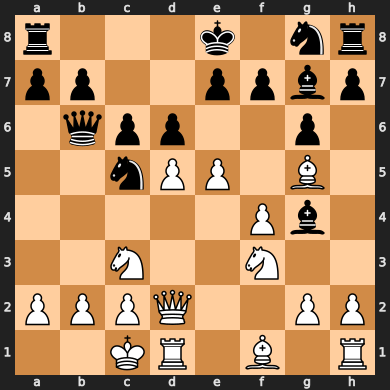

In [148]:
display(Math(r" \quad ".join(parts)))
display(board)

The fields are as follows:

- $A$: Piece placement
    - pawn = "P", knight = "N", bishop = "B", rook = "R", queen = "Q" and king = "K"
    - uppercase letters are white pieces, lowercase black pieces
    - digits from 1 to 8 indicate consecutive empty squares
    - for each rank (rank=row, 8 of them separated by "/") there are all the pieces described, starting from the a file (file=colum)
    - e.g.
- $B$: Active color: "w" for white to move, "b" for black
- $C$: [Castling](https://chess.fandom.com/wiki/Castling) availability
    - indicates which side (if any) can still castle (the right to castle can be lost once the king moves, something that you can't deduce from one single board position)
    - "K" for kingside castle, "Q" for queenside (lower case for black pieces), and "-" for none
- $D$: [En passant](https://chess.fandom.com/wiki/En_passant) target square
    - squares (in algebraic notation) over which a pawn has just passed while moving two squares
    - "-" for no squares
- $E$: Halfmove clock: number of halfmoves since the last capture or pawn advance (used for the [fifty-move rule](https://chess.fandom.com/wiki/Fifty_move_rule))
- $F$: Fullmove number: number of the moves since the beginning of the game

this whole project is about feature engineering, so extracting features from the FEN, blablabla...

In [149]:
from sklearn.preprocessing import FunctionTransformer

# Cleaning

The evaluation feature is a string that contains the [centipawn evaluation](https://chess.fandom.com/wiki/Centipawn), and in the case of forced checkmate in less than 22 moves (the engine's depth), a hashtag is included at the beginning together with the number of moves. This is an edge-case, which is of no interest for our current goals. Moreover, these cases represent less than 1% of the dataset, which is already big enough, so we can just eliminate these rows.

In [157]:
def remove_forced_checkmates(dataframe: pd.DataFrame) -> pd.DataFrame:
    return dataframe[~dataframe[EVALUATION].astype(str).str.contains("#")].copy()

hash_filter = FunctionTransformer(remove_forced_checkmates)

In [163]:
DATAFRAME = hash_filter.transform(DATAFRAME_RAW)
DATAFRAME.describe()

,FEN,Evaluation
count,9943,9943
unique,9943,1726
top,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,0
freq,1,943


We also see the evaluation has a vast range of values.

In [167]:
DATAFRAME[EVALUATION] = np.clip(DATAFRAME[EVALUATION], -1000, 1000)

DATAFRAME[EVALUATION].hist()
plt.show()

TypeError: '>=' not supported between instances of 'str' and 'int'


# Basic Features

The most natural indicator that one would consider to predict the advantage of the players is the piece count: how many pieces does each player have. So, we code the first transformer to extract the piece count from the FEN.

In [152]:
WHITE_PIECES = "WhitePieces"
BLACK_PIECES = "BlackPieces"

In [153]:
def extract_piece_count(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe.copy()

    def count(fen):
        temp_board = chess.Board(fen)
        white = sum(1 for p in temp_board.piece_map().values() if p.color)
        black = sum(1 for p in temp_board.piece_map().values() if not p.color)
        return white, black

    w, b = zip(*dataframe["FEN"].apply(count))
    out[WHITE_PIECES] = w
    out[BLACK_PIECES] = b

    return out

piece_transformer = FunctionTransformer(extract_piece_count, validate=False)

In [154]:
DATAFRAME_PIECE_COUNT = piece_transformer.transform(DATAFRAME)

In [166]:
df["Scoring"] = np.clip(df["Evaluation"], -1000, 1000)

X = df[["WhitePieces", "BlackPieces"]]
y = df["Scoring"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

TypeError: '>=' not supported between instances of 'str' and 'int'

In [61]:
df

,FEN,Evaluation,WhitePieces,BlackPieces,Scoring
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10,16,16,-10
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,56,16,16,56
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9,16,16,-9
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,52,16,16,52
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26,16,16,-26
...,...,...,...,...,...
9995,r2q1rk1/pb1pppbp/np3np1/2p5/2P5/1PN2NP1/PB1PPP...,-21,16,16,-21
9996,r2q1rk1/pb2ppbp/np3np1/2pp4/2P5/1PN2NP1/PB1PPP...,30,16,16,30
9997,r2q1rk1/pb2ppbp/np3np1/2pN4/2P5/1P3NP1/PB1PPPB...,-51,16,15,-51
9998,r2q1rk1/pb2ppbp/np4p1/2pn4/2P5/1P3NP1/PB1PPPBP...,14,15,15,14


## Check-mate


https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/discussion/497472#2775858

In [65]:
def sign_accuracy(y_true, y_pred):
    true_sign = np.sign(y_true)
    pred_sign = np.sign(y_pred)

    true_sign[true_sign == 0] = 1
    pred_sign[pred_sign == 0] = 1

    correct = np.sum(true_sign == pred_sign)
    return correct / len(y_true)

def sign_recall(y_true, y_pred, positive=True):
    true_sign = np.sign(y_true)
    pred_sign = np.sign(y_pred)
    true_sign[true_sign == 0] = 1
    pred_sign[pred_sign == 0] = 1

    if positive:
        mask = true_sign > 0
    else:
        mask = true_sign < 0

    if np.sum(mask) == 0:
        return np.nan
    return np.sum(pred_sign[mask] == true_sign[mask]) / np.sum(mask)

In [165]:
df["Scoring"].hist(bins=30)
plt.tight_layout()
plt.show()

KeyError: 'Scoring'

Mean Squared Error: 132762.3175
Sign accuracy: 0.6715
Positive sign recall: 0.9669354838709677
Negative sign recall: 0.18947368421052632


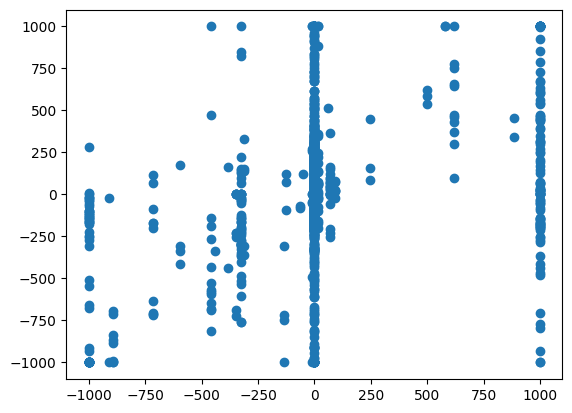

In [67]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
acc = sign_accuracy(y_test, y_pred)
recall_pos = sign_recall(y_test, y_pred, positive=True)
recall_neg = sign_recall(y_test, y_pred, positive=False)

print("Mean Squared Error:", mse)
print("Sign accuracy:", acc)
print("Positive sign recall:", recall_pos)
print("Negative sign recall:", recall_neg)

plt.scatter(y_pred, y_test)
plt.show()

Mean Squared Error: 85817.56976630712
Sign accuracy: 0.6625
Positive sign recall: 0.8629032258064516
Negative sign recall: 0.3355263157894737


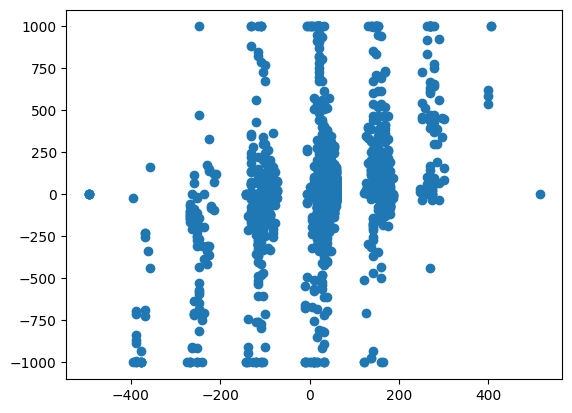

In [95]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
acc = sign_accuracy(y_test, y_pred)
recall_pos = sign_recall(y_test, y_pred, positive=True)
recall_neg = sign_recall(y_test, y_pred, positive=False)

print("Mean Squared Error:", mse)
print("Sign accuracy:", acc)
print("Positive sign recall:", recall_pos)
print("Negative sign recall:", recall_neg)

plt.scatter(y_pred, y_test)
plt.show()

C:\Users\natan\MatCAD\3\3.1\Aprenentatge Computacional\Chess Evaluations\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



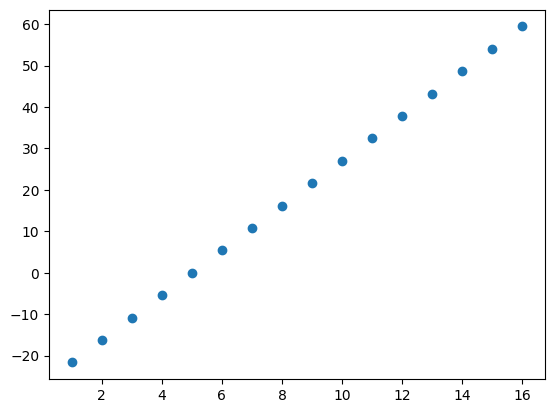

In [96]:
plt.scatter(range(1, 17), model.predict([[x, x] for x in range(1, 17)]))

C:\Users\natan\MatCAD\3\3.1\Aprenentatge Computacional\Chess Evaluations\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


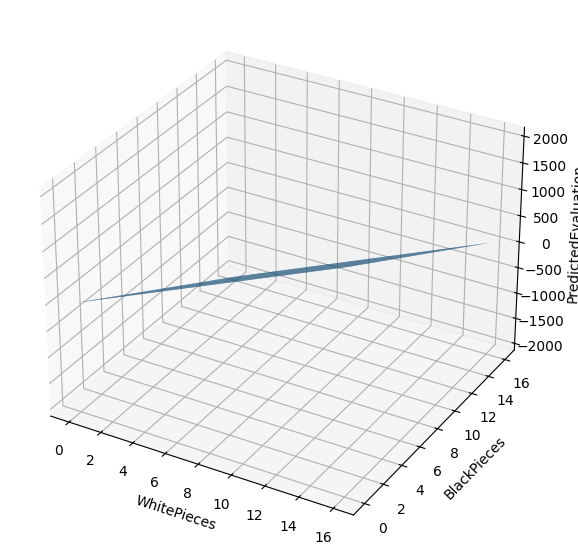

In [72]:
# create grid
w_vals = np.linspace(0, 16, 16)
b_vals = np.linspace(0, 16, 16)
W, B = np.meshgrid(w_vals, b_vals)

# flatten and predict
grid = np.column_stack([W.ravel(), B.ravel()])
Z = model.predict(grid).reshape(W.shape)

# plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(W, B, Z)
ax.set_xlabel("WhitePieces")
ax.set_ylabel("BlackPieces")
ax.set_zlabel("PredictedEvaluation")

plt.show()

In [90]:
import numpy as np
import plotly.graph_objects as go

# grid
w_vals = np.linspace(df["WhitePieces"].min(), df["WhitePieces"].max(), 50)
b_vals = np.linspace(df["BlackPieces"].min(), df["BlackPieces"].max(), 50)
W, B = np.meshgrid(w_vals, b_vals)

# predictions
grid = np.column_stack([W.ravel(), B.ravel()])
Z = model.predict(grid).reshape(W.shape)

fig = go.Figure(
    data=go.Surface(x=W, y=B, z=Z)
)

fig.update_layout(
    scene=dict(
        xaxis_title="WhitePieces",
        yaxis_title="BlackPieces",
        zaxis_title="PredictedEvaluation"
    ),
    width=800,
    height=600
)

fig.show()

C:\Users\natan\MatCAD\3\3.1\Aprenentatge Computacional\Chess Evaluations\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

